## Dimensionality Reduction & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
df = pd.read_csv('second_hand_cars.csv')
print("Shape:", df.shape)
df.head()

Shape: (2500, 16)


,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [4]:
df.describe().round(2)

,Make Year,Mileage,Price
count,2500.00,2500.00,2500.00
mean,2019.52,104777.79,608120.90
std,2.89,55544.49,231056.13
min,2015.00,10010.00,200176.00
25%,2017.00,56313.00,407791.00
50%,2020.00,104209.50,612012.50
75%,2022.00,152149.25,804567.00
max,2024.00,199755.00,999826.00


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Company Name                  0
Car Name                      0
Variant                     262
Fuel Type                     0
Tyre Condition                0
Make Year                     0
Owner Type                    0
Registration Number           0
Mileage                       0
Price                         0
Transmission Type             0
Body Color                    0
Service Record                0
Insurance                     0
Registration Certificate      0
Accessories                 482
dtype: int64


### Data Preparation

In [ ]:
#Dropped the Registration Number because it is a unique identifier with no predictive value
df.drop(columns=['Registration Number'], inplace=True)

In [7]:
#Fill in missing Variant with 'Unknown'
df['Variant'].fillna('Unknown', inplace=True)

0             EX
1            RXE
2            RXE
3       Highline
4       Highline
          ...   
2495         RXE
2496          LE
2497         RXE
2498          XL
2499          GT
Name: Variant, Length: 2500, dtype: str

In [8]:
#Dropped Accessories cplumn because, it has too many missing and too high cardinality
df.drop(columns=['Accessories'], inplace=True)

In [9]:
#Checked for duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [10]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (2500, 14)


In [11]:
#Converted Make Year to integer
df['Make Year'] = df['Make Year'].astype(int)
df['Mileage'] = df['Mileage'].astype(float)
df['Price'] = df['Price'].astype(float)

print(df.dtypes)

Company Name                    str
Car Name                        str
Variant                         str
Fuel Type                       str
Tyre Condition                  str
Make Year                     int64
Owner Type                      str
Mileage                     float64
Price                       float64
Transmission Type               str
Body Color                      str
Service Record                  str
Insurance                       str
Registration Certificate        str
dtype: object


### Feature Engineering

In [12]:
#Car Age
df['Car_Age'] = 2024 - df['Make Year']

#Price per km
df['Price_per_km'] = df['Price'] / (df['Mileage'] + 1)  # +1 to avoid division by zero

print("New features added:")
print(df[['Make Year', 'Car_Age', 'Mileage', 'Price', 'Price_per_km']].head())

New features added:
   Make Year  Car_Age  Mileage     Price  Price_per_km
0       2018        6  52798.0  759107.0     14.377299
1       2020        4  43412.0  505071.0     11.634096
2       2022        2  95219.0  635322.0      6.672149
3       2024        0  70370.0  483152.0      6.865783
4       2018        6  85852.0  712961.0      8.304439


### Encoding Categorical Features

In [13]:
#Label Encoding for categorical columns
le = LabelEncoder()

cat_cols = ['Company Name', 'Car Name', 'Variant', 'Fuel Type',
            'Tyre Condition', 'Owner Type', 'Transmission Type',
            'Body Color', 'Service Record', 'Insurance',
            'Registration Certificate']

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoding complete. Shape:", df_encoded.shape)
df_encoded.head()

Encoding complete. Shape: (2500, 16)


,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Car_Age,Price_per_km
0,5,2,0,0,0,2018,1,52798.0,759107.0,2,3,449,0,1,6,14.377299
1,4,7,4,2,1,2020,2,43412.0,505071.0,0,4,280,0,0,4,11.634096
2,4,0,4,2,1,2022,1,95219.0,635322.0,1,0,848,0,0,2,6.672149
3,6,7,2,1,2,2024,2,70370.0,483152.0,1,4,830,1,0,0,6.865783
4,0,5,2,2,2,2018,1,85852.0,712961.0,1,6,320,0,1,6,8.304439


### Feature Scaling

In [15]:
#Normalize numerical features
features = df_encoded.drop(columns=['Price'])
target = df_encoded['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (2500, 15)


### Correlation Analysis

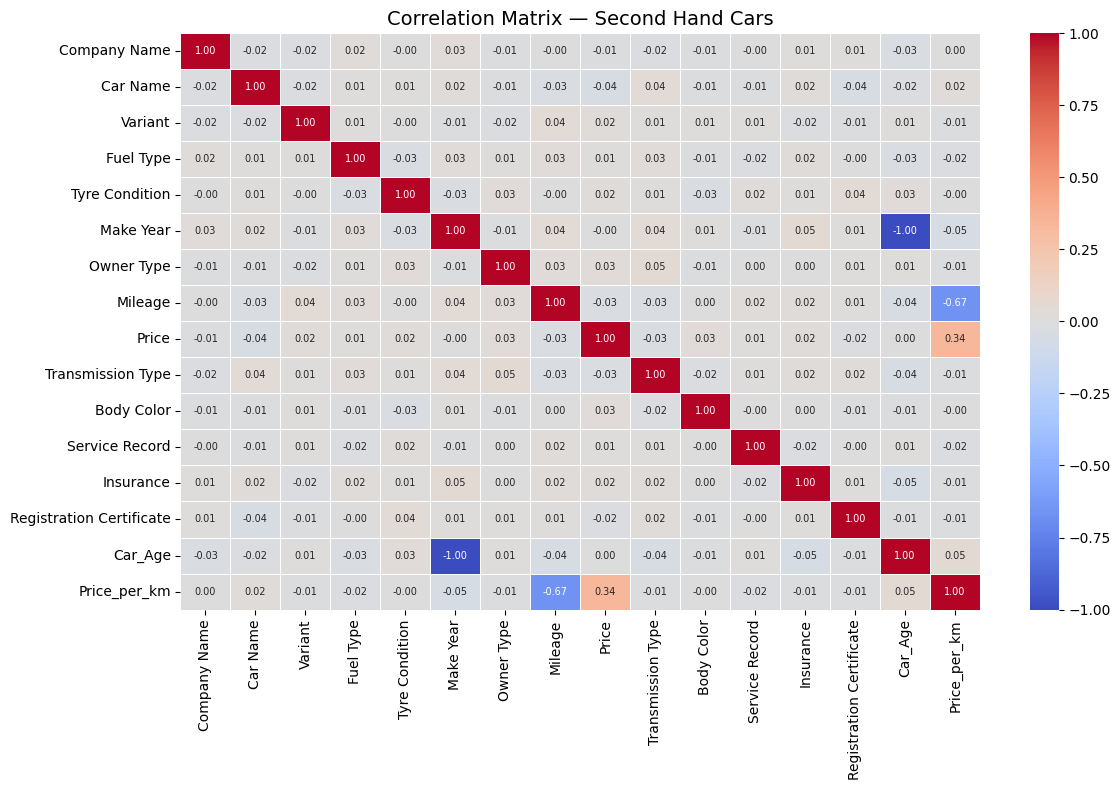

In [16]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr().round(2), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix — Second Hand Cars', fontsize=14)
plt.tight_layout()
plt.show()

### Dimensionality Reduction

#### 5.1 Principal Component Analysis (PCA)

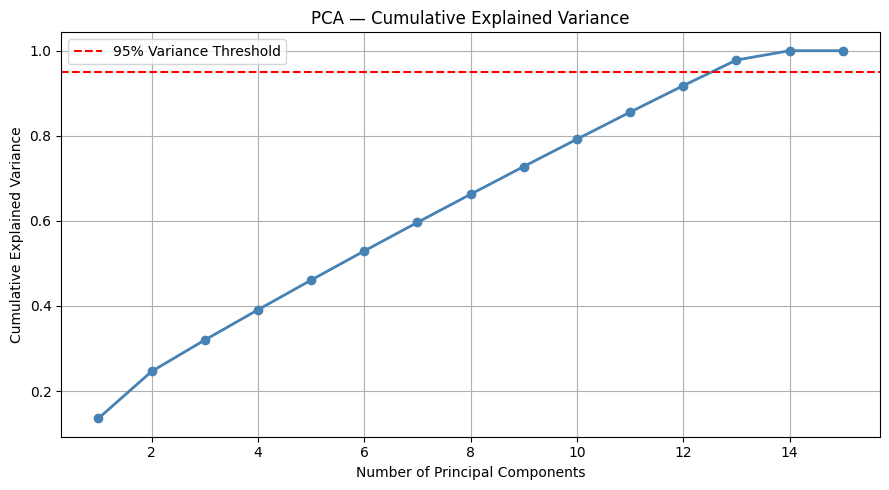

PC1: 0.1359 (13.59%)
PC2: 0.1104 (11.04%)
PC3: 0.0737 (7.37%)
PC4: 0.0710 (7.10%)
PC5: 0.0698 (6.98%)
PC6: 0.0684 (6.84%)
PC7: 0.0671 (6.71%)
PC8: 0.0661 (6.61%)
PC9: 0.0652 (6.52%)
PC10: 0.0642 (6.42%)


In [17]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_),
         marker='o', color='steelblue', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

for i, var in enumerate(pca_full.explained_variance_ratio_[:10]):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

In [18]:
#Applying PCA keeping components that explain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features  : {X_scaled.shape[1]}")
print(f"After PCA          : {X_pca.shape[1]}")
print(f"Variance retained  : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original features  : 15
After PCA          : 13
Variance retained  : 97.81%


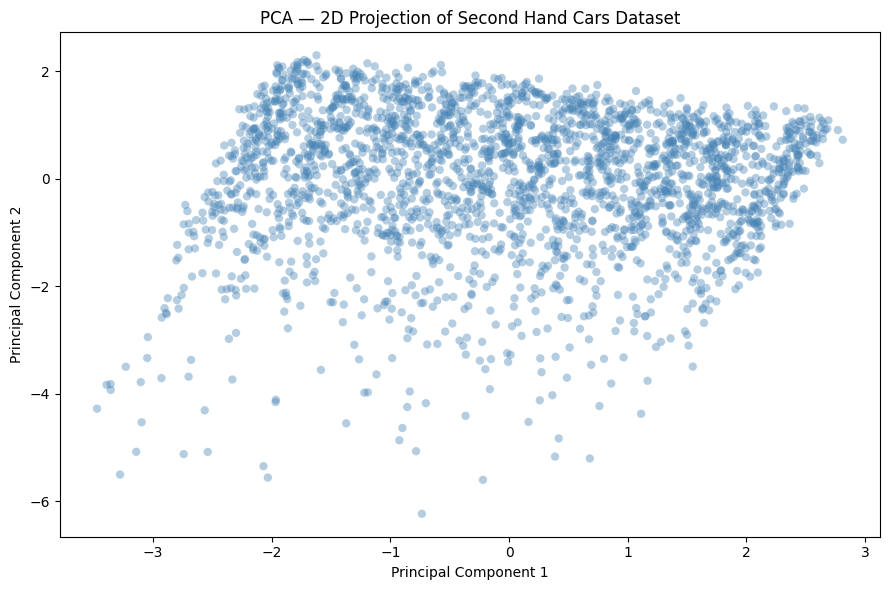

In [19]:
#Visualising the first 2 PCs in 2D
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, color='steelblue', edgecolors='none')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA — 2D Projection of Second Hand Cars Dataset')
plt.tight_layout()
plt.show()

### K-Means Clustering

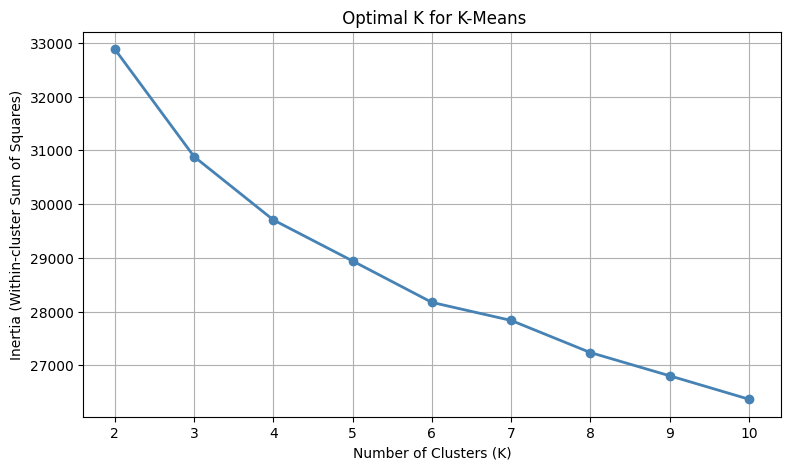

In [21]:
#Finding the most optimal K using the Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title(' Optimal K for K-Means')
plt.grid(True)
plt.show();

In [ ]:
#Applying means with the optimal k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

#Silhouette Score
sil_score = silhouette_score(X_pca, kmeans_labels)
print(f"K-Means Silhouette Score (k={optimal_k}): {sil_score:.4f}")

K-Means Silhouette Score (k=4): 0.0740


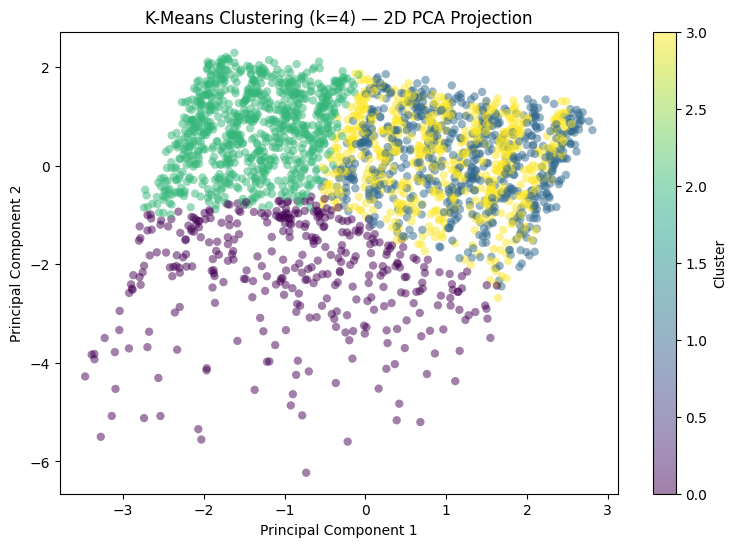

In [23]:
#Visualising the K Means Clusters in 2D
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=kmeans_labels, cmap='viridis',
                      alpha=0.5, edgecolors='none')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Clustering (k={optimal_k}) — 2D PCA Projection')
plt.show();

###  DBSCAN Clustering

In [24]:
#Applying DBSCAN on the reduced data
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X_pca)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Number of clusters found : {n_clusters}")
print(f"Number of noise points   : {n_noise}")

#Silhouette score
mask = db_labels != -1
if mask.sum() > 1 and len(set(db_labels[mask])) > 1:
    sil_db = silhouette_score(X_pca[mask], db_labels[mask])
    print(f"DBSCAN Silhouette Score  : {sil_db:.4f}")

Number of clusters found : 0
Number of noise points   : 2500


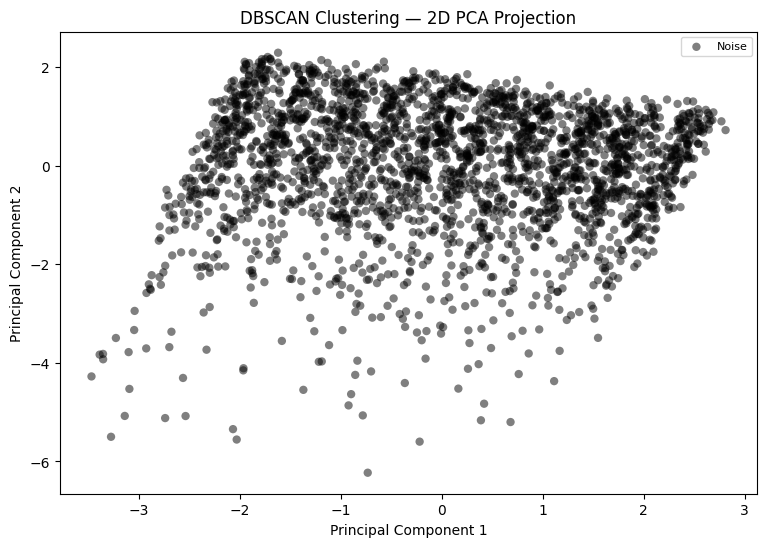

In [25]:
#Visualising the DBSCAN clusters in 2D
plt.figure(figsize=(9, 6))
unique_labels = set(db_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        label = 'Noise'
    else:
        label = f'Cluster {k}'
    mask = db_labels == k
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[col], alpha=0.5, label=label, edgecolors='none')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering — 2D PCA Projection')
plt.legend(loc='best', fontsize=8)
plt.show();

###  Modelling and Evaluation

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, target, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing  set:", X_test.shape)

Training set: (2000, 13)
Testing  set: (500, 13)


In [28]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(" Linear Regression")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_lr):,.2f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.2f}")
print(f"  R²   : {r2_score(y_test, y_pred_lr):.4f}")

 Linear Regression
  MAE  : 199,316.24
  RMSE : 229,566.86
  R²   : 0.0490


In [30]:
#Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_rf):,.2f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.2f}")
print(f"  R²   : {r2_score(y_test, y_pred_rf):.4f}")

Random Forest
  MAE  : 200,264.59
  RMSE : 231,934.46
  R²   : 0.0293


In [ ]:
#Comparing the models
comparison = {
    'Linear Regression': {
        'MAE' : mean_absolute_error(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        'R²'  : r2_score(y_test, y_pred_lr)
    },
    'Random Forest': {
        'MAE' : mean_absolute_error(y_test, y_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'R²'  : r2_score(y_test, y_pred_rf)
    }
}

pd.DataFrame(comparison).T.round(4)

,MAE,RMSE,R²
Linear Regression,199316.2389,229566.8570,0.0490
Random Forest,200264.5869,231934.4634,0.0293


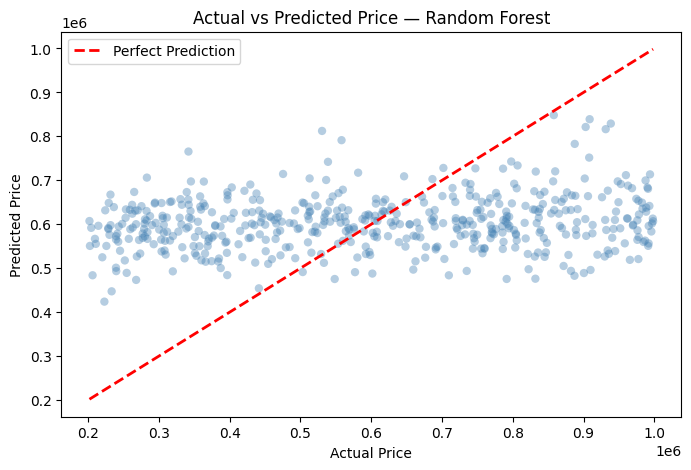

In [32]:
#Actual vs Predicted-Random Forest
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price — Random Forest')
plt.legend()
plt.show();